# Validación y exploración del datacubo histórico

Este notebook es de **solo lectura**: comprueba el datacubo EGIF + ERA5 + topografía + CORINE ya generado. No descarga datos ni ejecuta el pipeline.

**Contrato temporal:** desde 2019-01-01 hasta la última fecha registrada en el XML EGIF. La meteorología y sus acumulados corresponden al día T (sin desplazamiento temporal).

In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

plt.style.use('default')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white'})
sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
CUBE_PATH = ROOT / 'data/processed/datacube/galicia_1km.nc'
assert CUBE_PATH.exists(), f'No se encuentra el datacubo: {CUBE_PATH}'
print(f'Leyendo: {CUBE_PATH}')

Leyendo: C:\Users\alfon\PycharmProjects\Sistema-deteccion-incendios\data\processed\datacube\galicia_1km.nc


In [29]:
cube = xr.open_dataset(CUBE_PATH)
display(cube)
print('Atributos globales:')
for key, value in cube.attrs.items():
    print(f'  - {key}: {value}')

<xarray.Dataset> Size: 7GB
Dimensions:                       (y: 225, x: 203, time: 1791)
Coordinates:
  * y                             (y) int64 2kB 2245000 2246000 ... 2469000
  * x                             (x) int64 2kB 2760000 2761000 ... 2962000
  * time                          (time) datetime64[ns] 14kB 2019-01-01 ... 2...
    number                        int64 8B ...
Data variables: (12/58)
    is_galicia                    (y, x) uint8 46kB ...
    elevation_mean                (y, x) float32 183kB ...
    elevation_std                 (y, x) float32 183kB ...
    slope_mean                    (y, x) float32 183kB ...
    slope_std                     (y, x) float32 183kB ...
    roughness_mean                (y, x) float32 183kB ...
    ...                            ...
    temperature_mean_7d           (time, y, x) float32 327MB ...
    relative_humidity_mean_7d     (time, y, x) float32 327MB ...
    consecutive_dry_days          (time, y, x) float32 327MB ...
    target_ignicion               (time, y, x) float32 327MB ...
    burned_area_ha                (time, y, x) float32 327MB ...
    large_fire_500ha              (time, y, x) float32 327MB ...
Attributes:
    title:            Galicia wildfire historical datacube
    period:           2019-01-01 to 2023-11-26
    target_contract:  All dates are covered by the supplied EGIF XML; 0 means...
    time_contract:    No temporal shift; meteorological accumulations include...

Atributos globales:
  - title: Galicia wildfire historical datacube
  - period: 2019-01-01 to 2023-11-26
  - target_contract: All dates are covered by the supplied EGIF XML; 0 means no ignition.
  - time_contract: No temporal shift; meteorological accumulations include date T.


## 1. Contrato, dimensiones y esquema

In [30]:
EXPECTED_START = pd.Timestamp('2019-01-01')
REQUIRED_VARIABLES = {
    'is_galicia', 'elevation_mean', 'slope_mean', 'forest_cover_fraction',
    'temperature_max_12_18h', 'relative_humidity_min_12_18h',
    'wind_speed_max_12_18h', 'precipitation_sum_30d',
    'target_ignicion',
}
dates = pd.DatetimeIndex(cube.time.values)
assert dates.min() == EXPECTED_START
assert len(dates) == len(pd.date_range(dates.min(), dates.max()))
assert REQUIRED_VARIABLES.issubset(cube.data_vars), REQUIRED_VARIABLES - set(cube.data_vars)
assert cube['is_galicia'].dtype.kind in 'biu'

n_active = int(cube['is_galicia'].sum())
summary = pd.DataFrame({
    'medida': ['días', 'celdas eje y', 'celdas eje x', 'celdas Galicia', 'variables'],
    'valor': [len(dates), cube.sizes['y'], cube.sizes['x'], n_active, len(cube.data_vars)],
})
display(summary)
print('✓ Contrato espacial, temporal y variables mínimas correcto.')

,medida,valor
0,días,1791
1,celdas eje y,225
2,celdas eje x,203
3,celdas Galicia,29601
4,variables,58


✓ Contrato espacial, temporal y variables mínimas correcto.


In [31]:
groups = {
    'topografía': ['elevation_mean', 'elevation_std', 'slope_mean', 'slope_std', 'roughness_mean', 'roughness_std'],
    'orientación': [name for name in cube.data_vars if name.startswith('aspect_')],
    'CORINE': ['artificial', 'agriculture', 'broadleaf_forest', 'coniferous_forest', 'mixed_forest', 'scrub', 'open_spaces', 'wetlands', 'water', 'forest_cover_fraction'],
    'calendario': ['year', 'month', 'iso_week', 'day_of_year', 'day_of_week', 'is_weekend', 'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos'],
    'meteorología': [name for name in cube.data_vars if name.startswith(('temperature_', 'relative_humidity_', 'wind_speed_', 'precipitation_', 'consecutive_'))],
    'resultado / auditoría': ['target_ignicion', 'burned_area_ha', 'large_fire_500ha'],
}
for group, names in groups.items():
    print(f'\n{group.upper()} ({len(names)}):')
    print(', '.join(names))


TOPOGRAFÍA (6):
elevation_mean, elevation_std, slope_mean, slope_std, roughness_mean, roughness_std

ORIENTACIÓN (9):
aspect_000_045_fraction, aspect_045_090_fraction, aspect_090_135_fraction, aspect_135_180_fraction, aspect_180_225_fraction, aspect_225_270_fraction, aspect_270_315_fraction, aspect_315_360_fraction, aspect_no_data_fraction

CORINE (10):
artificial, agriculture, broadleaf_forest, coniferous_forest, mixed_forest, scrub, open_spaces, wetlands, water, forest_cover_fraction

CALENDARIO (10):
year, month, iso_week, day_of_year, day_of_week, is_weekend, day_of_year_sin, day_of_year_cos, month_sin, month_cos

METEOROLOGÍA (19):
temperature_mean, temperature_min, temperature_max, temperature_max_12_18h, relative_humidity_mean, relative_humidity_min, relative_humidity_min_12_18h, wind_speed_mean, wind_speed_max, wind_speed_max_12_18h, precipitation_sum, precipitation_sum_1d, precipitation_sum_3d, precipitation_sum_7d, precipitation_sum_14d, precipitation_sum_30d, temperature_me

## 2. Validaciones de rango y completitud

In [32]:
active = cube['is_galicia'] == 1
static_vars = groups['topografía'] + groups['orientación'] + groups['CORINE']
static_missing = {name: float((cube[name].isnull() & active).sum() / active.sum()) for name in static_vars}
display(pd.Series(static_missing, name='fracción_na').sort_values().to_frame())
assert max(static_missing.values()) < 0.01, 'Hay demasiados NaN en capas estáticas.'

meteo_checks = {
    'temperatura (°C)': ('temperature_min', -45, 55),
    'humedad relativa (%)': ('relative_humidity_min', 0, 100),
    'viento (m/s)': ('wind_speed_max', 0, 80),
    'precipitación (mm)': ('precipitation_sum', 0, 500),
    'días secos': ('consecutive_dry_days', 0, 500),
}
range_rows = []
for label, (name, low, high) in meteo_checks.items():
    values = cube[name].where(active)
    observed_min, observed_max = float(values.min()), float(values.max())
    range_rows.append([label, name, observed_min, observed_max, low <= observed_min and observed_max <= high])
ranges = pd.DataFrame(range_rows, columns=['variable', 'nombre', 'mínimo', 'máximo', 'rango_plausible'])
display(ranges)
assert ranges['rango_plausible'].all(), 'Hay valores meteorológicos fuera de un rango físico plausible.'

for longer, shorter in [('precipitation_sum_3d', 'precipitation_sum'), ('precipitation_sum_7d', 'precipitation_sum_3d'), ('precipitation_sum_14d', 'precipitation_sum_7d'), ('precipitation_sum_30d', 'precipitation_sum_14d')]:
    invalid_fraction = float(((cube[longer] + 1e-6) < cube[shorter]).where(active).mean())
    print(f'{longer} ≥ {shorter}: fracción que incumple = {invalid_fraction:.6f}')
    assert invalid_fraction < 1e-6
print('✓ Capas estáticas completas y acumulados meteorológicos coherentes.')

,fracción_na
elevation_mean,0.0
elevation_std,0.0
slope_mean,0.0
slope_std,0.0
roughness_mean,0.0
roughness_std,0.0
aspect_000_045_fraction,0.0
aspect_045_090_fraction,0.0
aspect_090_135_fraction,0.0
aspect_135_180_fraction,0.0


,variable,nombre,mínimo,máximo,rango_plausible
0,temperatura (°C),temperature_min,-14.246429,25.650211,True
1,humedad relativa (%),relative_humidity_min,11.594326,99.056244,True
2,viento (m/s),wind_speed_max,2.609590,67.380363,True
3,precipitación (mm),precipitation_sum,0.000000,85.589973,True
4,días secos,consecutive_dry_days,0.000000,71.000000,True


precipitation_sum_3d ≥ precipitation_sum_1d: fracción que incumple = 0.000000
precipitation_sum_7d ≥ precipitation_sum_3d: fracción que incumple = 0.000000
precipitation_sum_14d ≥ precipitation_sum_7d: fracción que incumple = 0.000000
precipitation_sum_30d ≥ precipitation_sum_14d: fracción que incumple = 0.000000
✓ Capas estáticas completas y acumulados meteorológicos coherentes.


## 3. Mapas de comprobación

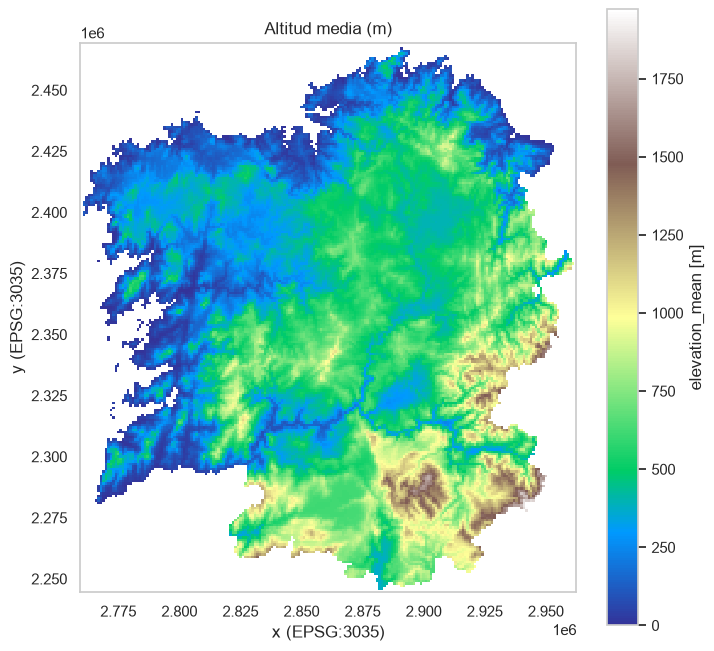

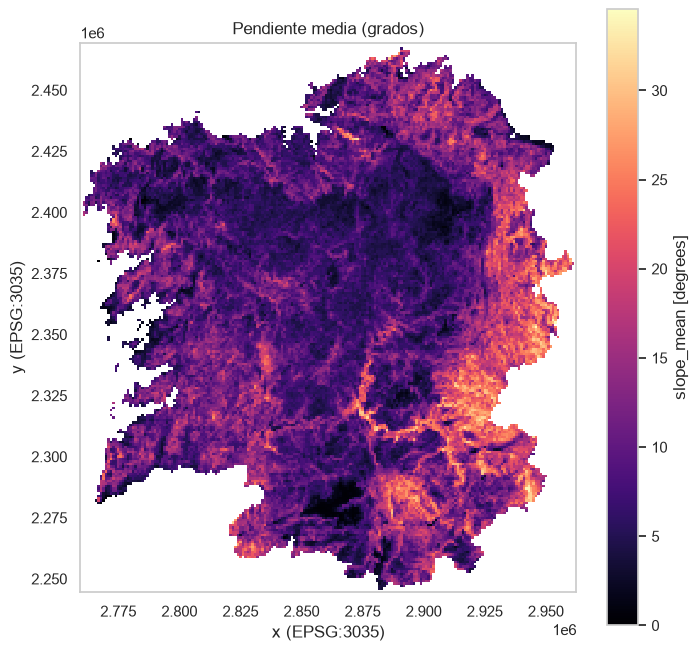

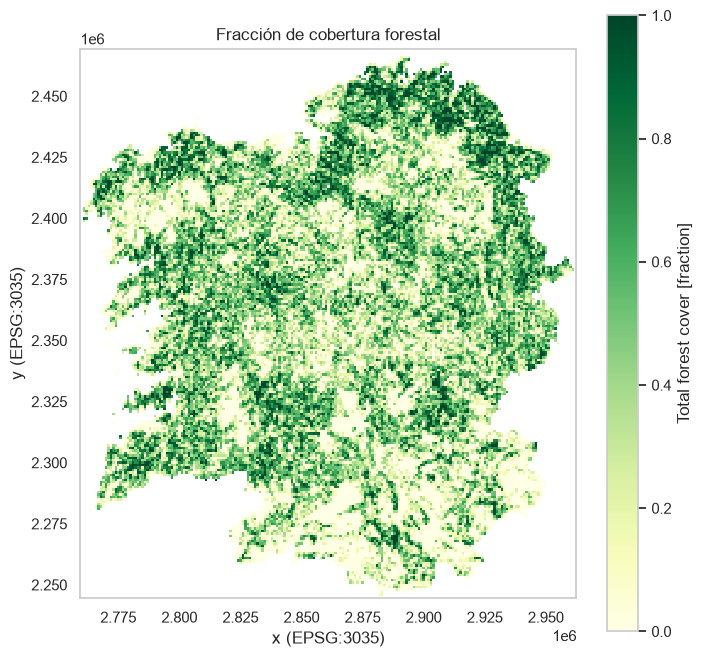

In [33]:
def plot_layer(data, title, cmap='viridis', vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')
    image = data.where(active).plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=True)
    ax.set_title(title)
    ax.set_xlabel('x (EPSG:3035)')
    ax.set_ylabel('y (EPSG:3035)')
    ax.set_aspect('equal')
    plt.show()

plot_layer(cube['elevation_mean'], 'Altitud media (m)', 'terrain')
plot_layer(cube['slope_mean'], 'Pendiente media (grados)', 'magma')
plot_layer(cube['forest_cover_fraction'], 'Fracción de cobertura forestal', 'YlGn', 0, 1)

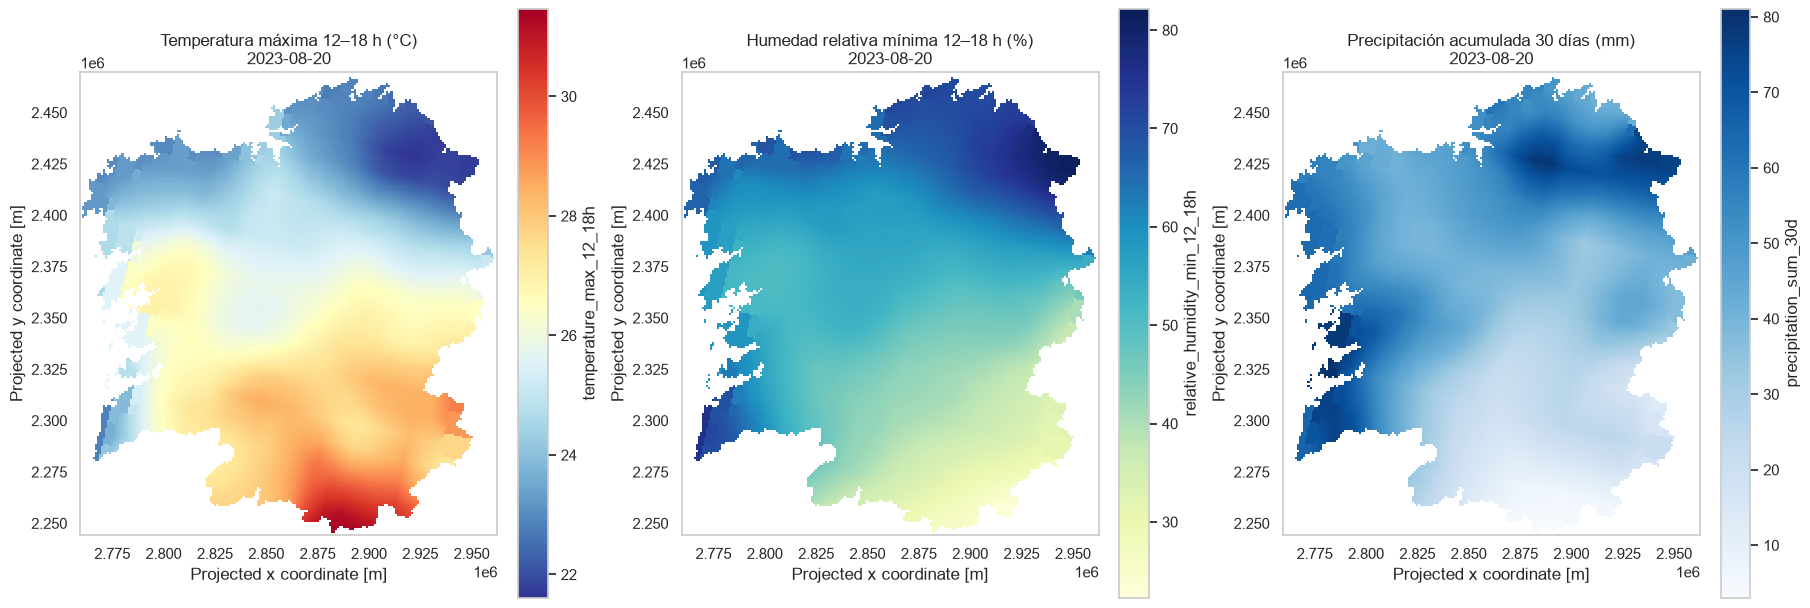

In [34]:
MAP_DATE = pd.Timestamp('2023-08-20')
if MAP_DATE not in dates:
    MAP_DATE = dates[len(dates) // 2]
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True, facecolor='white')
layers = [
    ('temperature_max_12_18h', 'Temperatura máxima 12–18 h (°C)', 'RdYlBu_r'),
    ('relative_humidity_min_12_18h', 'Humedad relativa mínima 12–18 h (%)', 'YlGnBu'),
    ('precipitation_sum_30d', 'Precipitación acumulada 30 días (mm)', 'Blues'),
]
for ax, (name, label, cmap) in zip(axes, layers):
    cube[name].sel(time=MAP_DATE).where(active).plot(ax=ax, cmap=cmap, add_colorbar=True)
    ax.set_title(f'{label}\n{MAP_DATE.date()}')
    ax.set_aspect('equal')
plt.show()

## 4. Cobertura EGIF y distribución del target

igniciones        
           mean     sum
año                    
2019   4.369863  1595.0
2020   4.040984  1479.0
2021   2.536986   926.0
2022   4.545206  1659.0
2023   1.606061   530.0

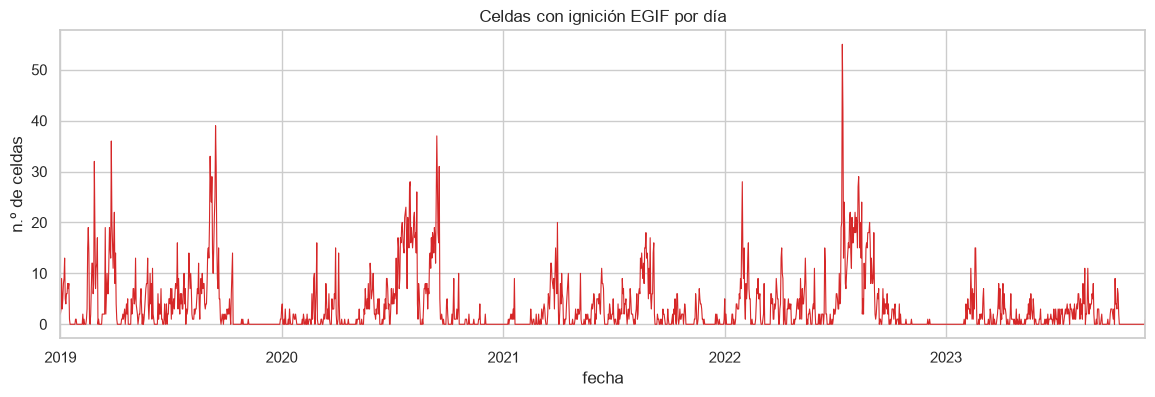

✓ Todo el intervalo del cubo está cubierto por EGIF; 0 significa ausencia de ignición.


In [35]:
daily_ignitions = cube['target_ignicion'].where(active).sum(dim=('y', 'x'), skipna=True).to_series()
coverage = pd.DataFrame({'igniciones': daily_ignitions})
coverage['año'] = coverage.index.year
display(coverage.groupby('año')[['igniciones']].agg(['mean', 'sum']))

fig, ax = plt.subplots(figsize=(14, 4), facecolor='white')
coverage['igniciones'].plot(ax=ax, color='tab:red', linewidth=0.8)
ax.set(title='Celdas con ignición EGIF por día', ylabel='n.º de celdas', xlabel='fecha')
plt.show()

assert int((cube['target_ignicion'].isnull() & active).sum()) == 0
print('✓ Todo el intervalo del cubo está cubierto por EGIF; 0 significa ausencia de ignición.')

## Cierre

Si todas las celdas anteriores finalizan sin excepciones, el datacubo es consistente para la fase de modelado. Cerrar el dataset libera el archivo en Windows.

In [36]:
cube.close()